In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import requests
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [2]:
cg_url = 'https://api.coingecko.com/api/v3/coins/ethereum/market_chart'
params = {'vs_currency': 'usd', 'days': '300', 'interval': 'daily'}

def fetch_market_data(url = cg_url, params = params):
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame({
        "timestamp":   [x[0] for x in data["prices"]],
        "price":       [x[1] for x in data["prices"]],
        "market_cap":  [x[1] for x in data["market_caps"]],
        "volume":      [x[1] for x in data["total_volumes"]],
    })

    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms").dt.normalize()
    df = df.drop_duplicates(subset="timestamp", keep="last")
    df[["price_change", "mcap_change", "volume_change"]] = (
        df[["price", "market_cap", "volume"]].pct_change()
    )
    df['price_ma_7'] = df['price'].rolling(window=7).mean()
    df['price_ma_30'] = df['price'].rolling(window=30).mean()

    df['dist_price_ma_7'] = (df['price'] - df['price_ma_7']) / df['price_ma_7']
    df['dist_price_ma_30'] = (df['price'] - df['price_ma_30']) / df['price_ma_30']


    df['target_tomorrow'] = df['price_change'].shift(-1)
    df['target_dir_tomorrow'] = (df['price_change'].shift(-1) > 0).astype(int)
    df_clean = df.dropna()

    return df_clean

df = fetch_market_data()

features = ['price_change', 'mcap_change', 'volume_change', 'dist_price_ma_7', 'dist_price_ma_30']
split_idx = int(len(df) * 0.8)
# x_train = df[features].iloc[:split_idx].values
# y_train = df['target_tomorrow'].iloc[:split_idx].values

# x_test = df[features].iloc[split_idx:].values
# y_test = df['target_tomorrow'].iloc[split_idx:].values

X = df[features].values
y = df['target_tomorrow'].values
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training data shapes:", x_train.shape, y_train.shape)
print("Testing data shapes:", x_test.shape, y_test.shape)

Training data shapes: (216, 5) (216,)
Testing data shapes: (54, 5) (54,)


Using Linear Model

R²: -0.00918719476046137
MAE: 0.01820798522399183
MSE: 0.0007041603292413553


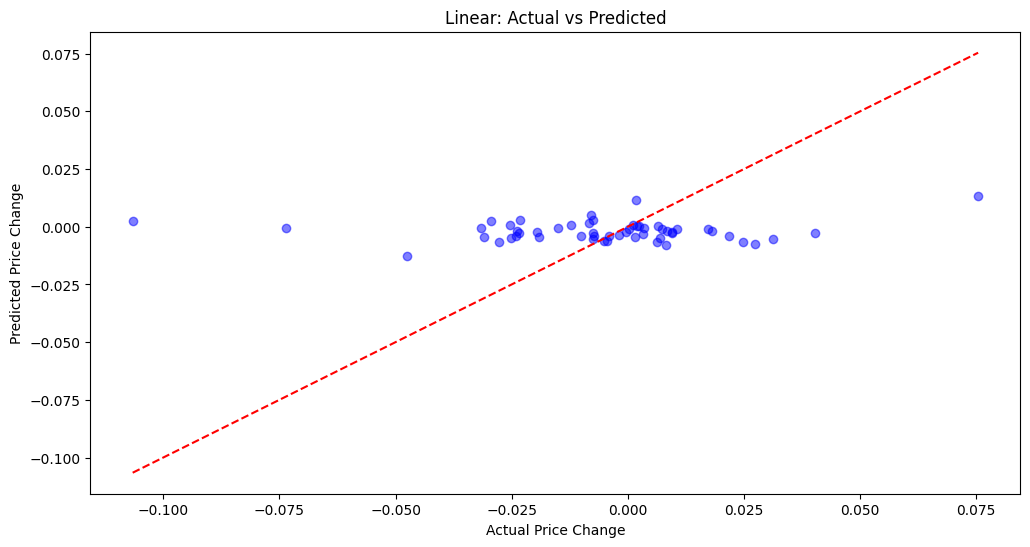

In [3]:

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price Change')
plt.ylabel('Predicted Price Change')
plt.title('Linear: Actual vs Predicted')
plt.show()


Using Random Forest Regressor

RF R² Score: -0.040732
RF MSE Score: 0.0007261707433208404
RF MAE Score: 0.01901110247225804


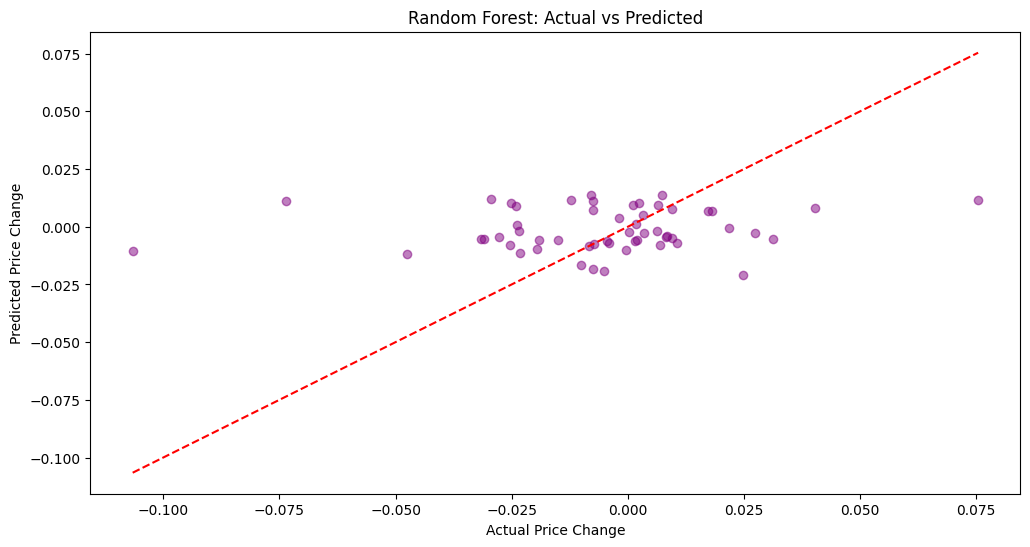

In [4]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=150, 
    max_depth=4,
    min_samples_leaf=5,
    random_state=42)
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print(f"RF R² Score: {r2_score(y_test,y_pred_rf):.6f}")
print(f"RF MSE Score: {mean_squared_error(y_test,y_pred_rf)}")
print(f"RF MAE Score: {mean_absolute_error(y_test,y_pred_rf)}")

plt.figure(figsize = (12,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price Change')
plt.ylabel('Predicted Price Change')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

Model Accuracy: 62.96%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.67      0.62      0.64        29
      UP (1)       0.59      0.64      0.62        25

    accuracy                           0.63        54
   macro avg       0.63      0.63      0.63        54
weighted avg       0.63      0.63      0.63        54



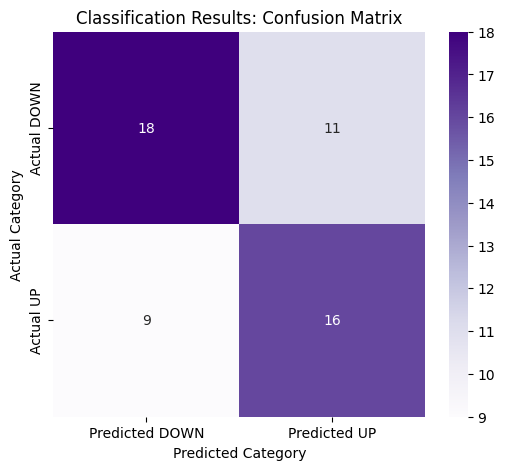

In [5]:
y = df['target_dir_tomorrow'].values

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

class_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)
class_model.fit(x_train, y_train)
y_pred_class = class_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred_class)
print(f"Model Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_class, target_names = ['Down (0)', 'UP (1)']))

cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Predicted DOWN', 'Predicted UP'], 
            yticklabels=['Actual DOWN', 'Actual UP'])
plt.title('Classification Results: Confusion Matrix')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

Initial Investment: $100.00
Final Strategy Wealth: $98.70 (-1.30%)
Final Buy & Hold Wealth: $76.83 (-23.17%)


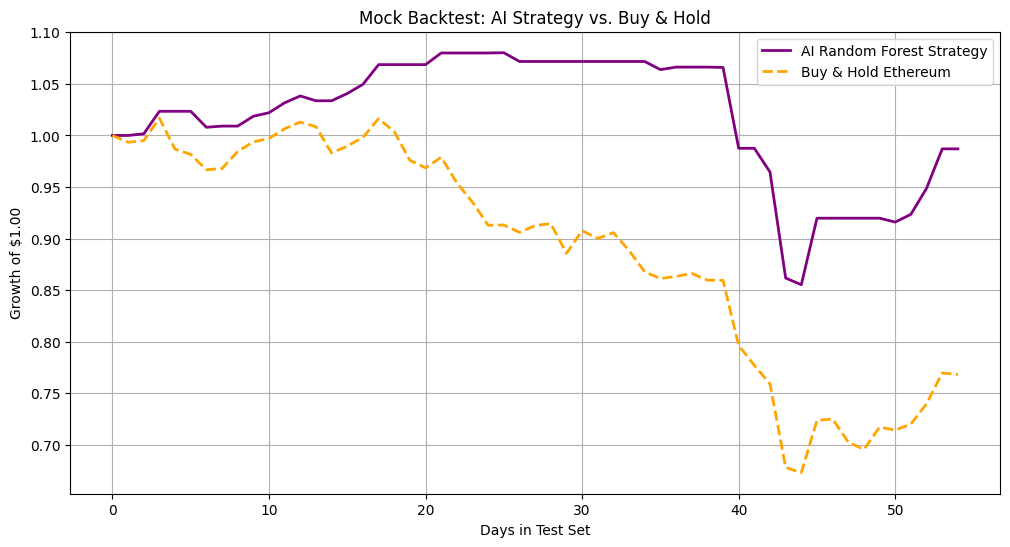

In [6]:
test_prices_pct = df['price_change'].iloc[split_idx:].values

strategy_wealth = [1.0] 
buy_and_hold_wealth = [1.0]


for i in range(len(y_pred_class)):
    actual_change = test_prices_pct[i]
    model_guess = y_pred_class[i]
    
    if model_guess > 0:
        next_wealth = strategy_wealth[-1] * (1 + actual_change)
    else:
        next_wealth = strategy_wealth[-1]
        
    strategy_wealth.append(next_wealth)
    
    next_bh = buy_and_hold_wealth[-1] * (1 + actual_change)
    buy_and_hold_wealth.append(next_bh)


final_strategy_return = (strategy_wealth[-1] - 1) * 100
final_bh_return = (buy_and_hold_wealth[-1] - 1) * 100

print(f"Initial Investment: $100.00")
print(f"Final Strategy Wealth: ${strategy_wealth[-1]*100:.2f} ({final_strategy_return:+.2f}%)")
print(f"Final Buy & Hold Wealth: ${buy_and_hold_wealth[-1]*100:.2f} ({final_bh_return:+.2f}%)")

plt.figure(figsize=(12, 6))
plt.plot(strategy_wealth, label='AI Random Forest Strategy', color='purple', linewidth=2)
plt.plot(buy_and_hold_wealth, label='Buy & Hold Ethereum', color='orange', linestyle='--', linewidth=2)
plt.title('Mock Backtest: AI Strategy vs. Buy & Hold')
plt.xlabel('Days in Test Set')
plt.ylabel('Growth of $1.00')
plt.legend()
plt.grid(True)
plt.show()
